In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.regularizers import l1_l2
from keras.optimizers import Adam, RMSprop, SGD
from keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE
import optuna
from sklearn.metrics import accuracy_score
import warnings as w
w.filterwarnings("ignore")

C:\Users\vinod\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("job_salary_prediction_dataset.csv")
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [6]:
df["remote_work"]

0         Hybrid
1             No
2             No
3            Yes
4            Yes
           ...  
249995        No
249996        No
249997       Yes
249998    Hybrid
249999        No
Name: remote_work, Length: 250000, dtype: object

In [7]:
df.head(5)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [8]:
df = df.drop(columns=["remote_work"])

In [9]:
df.head(5)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,0,165069


In [10]:
X = df.drop(columns = ["salary"])
y = df["salary"]

In [11]:
print(y.value_counts())

salary
140468    13
156899    11
131287    11
164406    10
126339    10
          ..
100077     1
215279     1
212857     1
79311      1
180294     1
Name: count, Length: 118956, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [14]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=21
)

In [15]:
from sklearn.preprocessing import StandardScaler

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
).flatten()

y_valid_scaled = y_scaler.transform(
    y_valid.values.reshape(-1, 1)
).flatten()

y_test_scaled = y_scaler.transform(
    y_test.values.reshape(-1, 1)
).flatten()

In [16]:
num_cols = X.select_dtypes(exclude = "object").columns
cat_cols = X.select_dtypes(include = "object").columns

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ["experience_years", "skills_count", "certifications"]

cat_cols = [
    "job_title",
    "education_level",
    "industry",
    "company_size",
    "location"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ]
)

In [18]:
X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_valid)
X_test_t = preprocessor.transform(X_test)

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Input

model = Sequential([
    Input(shape=(45,)),      # or Input(shape=(X_train_t.shape[1],))

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation="relu"),
    BatchNormalization(),

    Dense(16, activation="relu"),

    Dense(1, activation="linear")
])

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           5,888 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,665 (69.00 KB)

 Trainable params: 17,217 (67.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [21]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(),
    loss="mse",
    metrics=["mae"]
)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [23]:
print(type(X_train))
print(type(y_train))

print(X_train.dtype if hasattr(X_train, "dtype") else X_train.dtypes)
print(y_train.dtype)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
job_title           object
experience_years     int64
education_level     object
skills_count         int64
industry            object
company_size        object
location            object
certifications       int64
dtype: object
int64


In [24]:
history = model.fit(
    X_train_t,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 46s 9ms/step - loss: 15360264192.0000 - mae: 116950.0703 - val_loss: 3354402304.0000 - val_mae: 54842.4961
Epoch 2/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 37s 9ms/step - loss: 709394432.0000 - mae: 18921.2227 - val_loss: 167758624.0000 - val_mae: 6854.6045
Epoch 3/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - loss: 188116880.0000 - mae: 10365.2871 - val_loss: 1609160064.0000 - val_mae: 9115.1123
Epoch 4/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 32s 8ms/step - loss: 152533120.0000 - mae: 9528.7012 - val_loss: 1220293120.0000 - val_mae: 8138.9136
Epoch 5/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - loss: 135143584.0000 - mae: 9028.9385 - val_loss: 24722558976.0000 - val_mae: 11722.8379
Epoch 6/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 43s 9ms/step - loss: 122010696.0000 - mae: 8622.4854 - val_loss: 2759953664.0000 - val_mae: 6459.8530
Epoch 7/100
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 38s 9ms/step - loss: 111628352.0000 - mae: 8313.2891 - val_loss: 589668224.0000

In [25]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_pred = model.predict(X_test_t)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
R² Score : 0.9727
MAE      : 4812.0122
MSE      : 37963080.0000
RMSE     : 6161.4187


In [26]:
loss, mae = model.evaluate(X_test_t, y_test, verbose=0)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

Test Loss (MSE): 37963092.0
Test MAE: 4812.01318359375


In [27]:
def objective(trial):

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        5e-4,
        log=True
    )

    n_layers = trial.suggest_int(
        "n_layers",
        1,
        4
    )

    activation = trial.suggest_categorical(
        "activation",
        ["relu", "tanh"]
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["Adam", "RMSprop"]
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128]
    )

    model = Sequential()

    model.add(Input(shape=(X_train_t.shape[1],)))

    for i in range(n_layers):

        units = trial.suggest_int(
            f"units_{i}",
            32,
            256,
            step=32
        )

        dropout = trial.suggest_float(
            f"dropout_{i}",
            0.0,
            0.4
        )

        reg = trial.suggest_float(
            f"reg_{i}",
            1e-6,
            1e-4,
            log=True
        )

        model.add(
            Dense(
                units,
                activation=activation,
                kernel_regularizer=l1_l2(reg, reg)
            )
        )

        model.add(BatchNormalization())

        model.add(Dropout(dropout))

    model.add(Dense(1, activation="linear"))

    optimizer = {
        "Adam": Adam(
            learning_rate=learning_rate,
            clipnorm=1.0
        ),
        "RMSprop": RMSprop(
            learning_rate=learning_rate,
            clipnorm=1.0
        )
    }

    model.compile(
        optimizer=optimizer[optimizer_name],
        loss="mse",
        metrics=["mae"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    model.fit(
        X_train_t,
        y_train_scaled,
        validation_data=(X_val_t, y_valid_scaled),
        epochs=30,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred = model.predict(
        X_val_t,
        verbose=0
    ).flatten()

    if np.isnan(y_pred).any():
        return -1000

    if np.isinf(y_pred).any():
        return -1000

    r2 = r2_score(
        y_valid_scaled,
        y_pred
    )

    return r2

In [28]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=21)
)

study.optimize(
    objective,
    n_trials=20,
    show_progress_bar=True
)

[I 2026-06-28 14:33:26,032] A new study created in memory with name: no-name-87029296-3cae-464f-b39d-084d819b527e
Best trial: 0. Best value: 0.975803:   5%|▌         | 1/20 [15:13<4:49:16, 913.53s/it]

[I 2026-06-28 14:48:39,562] Trial 0 finished with value: 0.9758031429104755 and parameters: {'learning_rate': 0.00010815764691248018, 'n_layers': 2, 'activation': 'relu', 'optimizer': 'Adam', 'batch_size': 64, 'units_0': 160, 'dropout_0': 0.027828381845040218, 'reg_0': 5.430114258922557e-05, 'units_1': 64, 'dropout_1': 0.07124986462379934, 'reg_1': 9.814294812495115e-06}. Best is trial 0 with value: 0.9758031429104755.


Best trial: 0. Best value: 0.975803:  10%|█         | 2/20 [21:34<3:00:01, 600.08s/it]

[I 2026-06-28 14:55:00,220] Trial 1 finished with value: 0.9757759805956244 and parameters: {'learning_rate': 0.00040151349283863393, 'n_layers': 4, 'activation': 'relu', 'optimizer': 'RMSprop', 'batch_size': 128, 'units_0': 256, 'dropout_0': 0.3043024278658425, 'reg_0': 1.0797844664603127e-05, 'units_1': 64, 'dropout_1': 0.11947691664354627, 'reg_1': 3.697311912555775e-06, 'units_2': 96, 'dropout_2': 0.1840561335171904, 'reg_2': 1.226695349735026e-05, 'units_3': 64, 'dropout_3': 0.3199473307755906, 'reg_3': 2.840330638851899e-05}. Best is trial 0 with value: 0.9758031429104755.


Best trial: 0. Best value: 0.975803:  15%|█▌        | 3/20 [27:42<2:20:03, 494.32s/it]

...

[I 2026-06-28 16:42:20,222] Trial 17 finished with value: 0.9753283701801337 and parameters: {'learning_rate': 0.00026453846052255486, 'n_layers': 3, 'activation': 'tanh', 'optimizer': 'RMSprop', 'batch_size': 32, 'units_0': 64, 'dropout_0': 0.007310571610438826, 'reg_0': 5.871433361230593e-06, 'units_1': 128, 'dropout_1': 0.2181935511996075, 'reg_1': 1.1254417012047893e-06, 'units_2': 256, 'dropout_2': 0.03040919080422702, 'reg_2': 1.6322528277735326e-06}. Best is trial 9 with value: 0.9765856008683842.


Best trial: 9. Best value: 0.976586:  95%|█████████▌| 19/20 [2:10:27<03:38, 218.48s/it]

[I 2026-06-28 16:43:53,718] Trial 18 finished with value: 0.9758875895044499 and parameters: {'learning_rate': 0.0004916938904498825, 'n_layers': 1, 'activation': 'tanh', 'optimizer': 'Adam', 'batch_size': 32, 'units_0': 128, 'dropout_0': 0.08516604385462048, 'reg_0': 1.8423806904462883e-06}. Best is trial 9 with value: 0.9765856008683842.


Best trial: 9. Best value: 0.976586: 100%|██████████| 20/20 [2:12:06<00:00, 396.33s/it]

[I 2026-06-28 16:45:32,589] Trial 19 finished with value: 0.9752578413943689 and parameters: {'learning_rate': 0.00023988763084824158, 'n_layers': 3, 'activation': 'tanh', 'optimizer': 'RMSprop', 'batch_size': 128, 'units_0': 32, 'dropout_0': 0.04411635065340583, 'reg_0': 1.079226422976133e-06, 'units_1': 256, 'dropout_1': 0.2641920917280085, 'reg_1': 2.3301492784593902e-05, 'units_2': 160, 'dropout_2': 0.38180155546925965, 'reg_2': 8.959459317661773e-05}. Best is trial 9 with value: 0.9765856008683842.


In [29]:
print("Best R² :", study.best_value)

print("\nBest Parameters")

for k, v in study.best_params.items():
    print(f"{k} : {v}")

Best R² : 0.9765856008683842

Best Parameters
learning_rate : 0.00011945951104018013
n_layers : 1
activation : tanh
optimizer : RMSprop
batch_size : 32
units_0 : 96
dropout_0 : 0.08730357805285066
reg_0 : 1.3346837681670034e-06


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l1_l2

model = Sequential()

# Input Layer
model.add(Input(shape=(X_train_t.shape[1],)))

# Hidden Layer
model.add(Dense(96,activation="tanh",kernel_initializer="glorot_uniform",kernel_regularizer=l1_l2(l1=1.3346837681670034e-06,l2=1.3346837681670034e-06)))

model.add(BatchNormalization())

model.add(Dropout(0.08730357805285066))

# Output Layer
model.add(Dense(1,activation="linear",kernel_initializer="glorot_uniform"))

In [31]:
from tensorflow.keras.optimizers import RMSprop

optimizer = RMSprop(learning_rate=0.00011945951104018013,clipnorm=1.0)

model.compile(optimizer=optimizer,loss="mse",metrics=["mae"])

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)

In [33]:
history = model.fit(X_train_t,y_train_scaled,validation_data=(X_val_t, y_valid_scaled),epochs=100,batch_size=32,callbacks=[early_stop],verbose=1)

Epoch 1/100
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.2222 - mae: 0.3517 - val_loss: 0.0406 - val_mae: 0.1558
Epoch 2/100
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0891 - mae: 0.2349 - val_loss: 0.0335 - val_mae: 0.1425
Epoch 3/100
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0719 - mae: 0.2110 - val_loss: 0.0277 - val_mae: 0.1306
Epoch 4/100
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0658 - mae: 0.2022 - val_loss: 0.0259 - val_mae: 0.1266
Epoch 5/100
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0635 - mae: 0.1984 - val_loss: 0.0251 - val_mae: 0.1249
Epoch 6/100
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 0.0620 - mae: 0.1958 - val_loss: 0.0242 - val_mae: 0.1226
Epoch 7/100
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0621 - mae: 0.1965 - val_loss: 0.0243 - val_mae: 0.1228
Epoch 8/100
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 0.0608 - mae: 0.1944 - val_loss: 0.0244 - val_mae: 0.1227
Epoch 9/100
5000/5000 ━━━━━━━━━━

In [34]:
y_pred_scaled = model.predict(X_test_t)

y_pred = y_scaler.inverse_transform(y_pred_scaled)

y_true = y_scaler.inverse_transform(y_test_scaled.reshape(-1,1))

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 549us/step


In [35]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Training predictions
y_train_pred_scaled = model.predict(X_train_t)

# Convert back to original salary scale
y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled)
y_train_actual = y_scaler.inverse_transform(y_train_scaled.reshape(-1,1))

print("Training Performance")
print("R² Score :", r2_score(y_train_actual, y_train_pred))
print("MAE      :", mean_absolute_error(y_train_actual, y_train_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_train_actual, y_train_pred)))

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 3s 502us/step
Training Performance
R² Score : 0.9772084110731318
MAE      : 4524.0902388671875
RMSE     : 5661.211826211866


In [36]:
# Test predictions
y_test_pred_scaled = model.predict(X_test_t)

# Convert back to original salary scale
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled)
y_test_actual = y_scaler.inverse_transform(y_test_scaled.reshape(-1,1))

print("Testing Performance")
print("R² Score :", r2_score(y_test_actual, y_test_pred))
print("MAE      :", mean_absolute_error(y_test_actual, y_test_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test_actual, y_test_pred)))

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Testing Performance
R² Score : 0.9770029369823107
MAE      : 4519.67975328125
RMSE     : 5653.563617195123


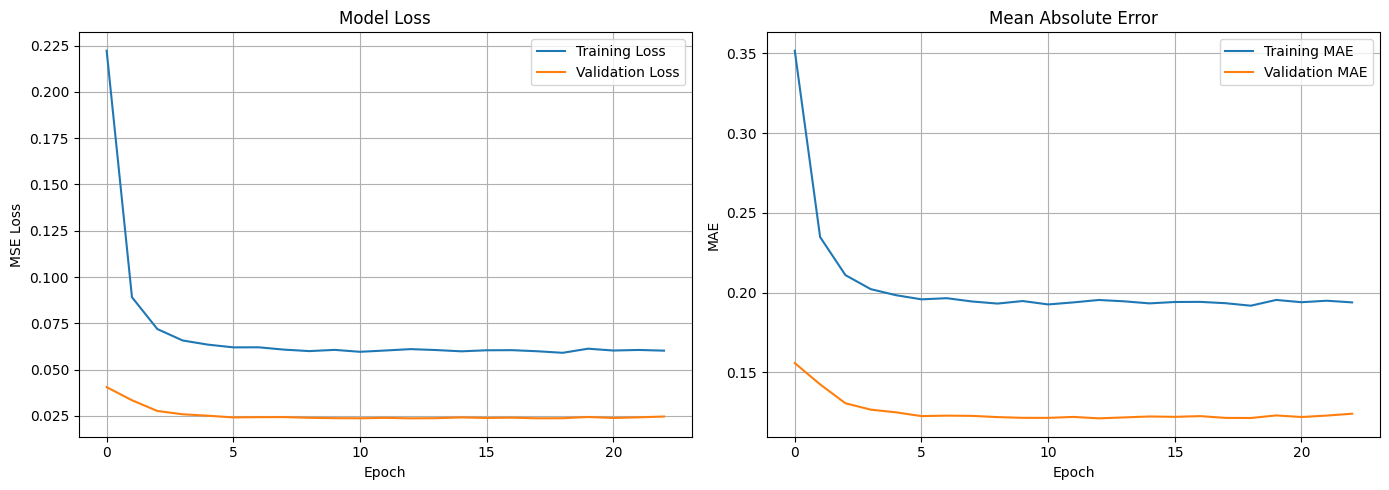

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title("Model Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(True)

# MAE Curve
axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title("Mean Absolute Error")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Actual vs Predicted

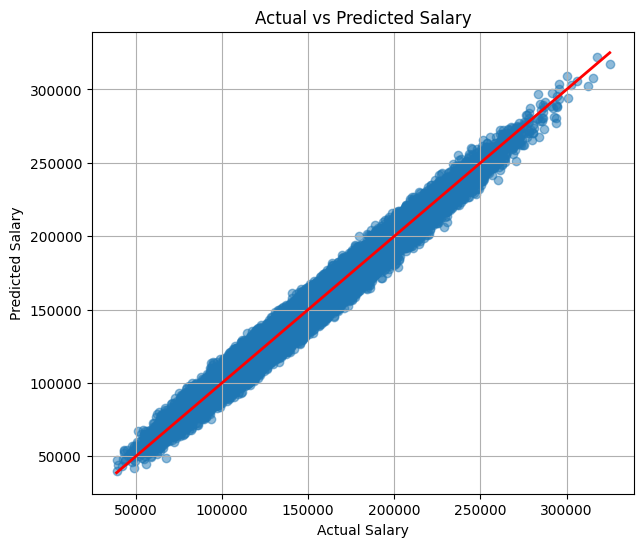

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         color='red', linewidth=2)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.grid(True)
plt.show()

In [47]:
import pickle

with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

model.save('model.keras')
print("Saved preprocessor.pkl and model.keras")

Saved preprocessor.pkl and model.keras


In [48]:
import pickle

with open("y_scaler.pkl", "wb") as f:
    pickle.dump(y_scaler, f)